In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
LG = pd.read_csv("../../data/summary_tabs/MW/Tara/SymphonyGroup_halo_cat.csv")

MW = pd.read_csv("../../data/summary_tabs/MW/Tara/SymphonyMilkyWay_halo_cat.csv")

LMC = pd.read_csv("../../data/summary_tabs/MW/Tara//SymphonyLMC_halo_cat.csv")

In [5]:
class NormalizeData:

    def __init__(self, df, model_label):

        self.df = df
        self.model_label = model_label
        self.logMvir_bar = np.log10(np.mean(10**self.df["log_mvir"]))
        self.logMvir_std = np.std(self.df["log_mvir"])

        #rockstar
        self.HAB_signal_80_rs()
        self.HAB_signal_85_rs()
        self.HAB_signal_90_rs()

        #symfind
        self.HAB_signal_80_sf()
        self.HAB_signal_85_sf()
        self.HAB_signal_90_sf()

    def measure_correlation(self, xkey, ykey):

        x = self.df[xkey]
        y = self.df[ykey]
        N = len(x)

        nanmask = ~np.isnan(x)

        rho, rho_err, p_val = jsm_stats.jackknife_correlation(x[nanmask], y[nanmask])
        return rho, rho_err, N

    def HAB_signal_80_rs(self):

        self.rho_80_rs = np.empty(shape=(4))
        self.rho_err_80_rs = np.empty(shape=(4))

        self.rho_80_rs[0], self.rho_err_80_rs[0], self.Nhosts_perbin = self.measure_correlation(xkey="log_Nsub_8_rs", ykey="log_1pz50")
        self.rho_80_rs[1], self.rho_err_80_rs[1], _ = self.measure_correlation(xkey="log_Nsub_8_rs", ykey="log_cvir_eff")
        self.rho_80_rs[2], self.rho_err_80_rs[2], _ = self.measure_correlation(xkey="log_fsub_8_rs", ykey="log_1pz50")
        self.rho_80_rs[3], self.rho_err_80_rs[3], _ = self.measure_correlation(xkey="log_fsub_8_rs", ykey="log_cvir_eff")

    def HAB_signal_85_rs(self):

        self.rho_85_rs = np.empty(shape=(4))
        self.rho_err_85_rs = np.empty(shape=(4))

        self.rho_85_rs[0], self.rho_err_85_rs[0], self.Nhosts_perbin = self.measure_correlation(xkey="log_Nsub_8.5_rs", ykey="log_1pz50")
        self.rho_85_rs[1], self.rho_err_85_rs[1], _ = self.measure_correlation(xkey="log_Nsub_8.5_rs", ykey="log_cvir_eff")
        self.rho_85_rs[2], self.rho_err_85_rs[2], _ = self.measure_correlation(xkey="log_fsub_8.5_rs", ykey="log_1pz50")
        self.rho_85_rs[3], self.rho_err_85_rs[3], _ = self.measure_correlation(xkey="log_fsub_8.5_rs", ykey="log_cvir_eff")

    def HAB_signal_90_rs(self):

        self.rho_90_rs = np.empty(shape=(4))
        self.rho_err_90_rs = np.empty(shape=(4))

        self.rho_90_rs[0], self.rho_err_90_rs[0], self.Nhosts_perbin = self.measure_correlation(xkey="log_Nsub_9_rs", ykey="log_1pz50")
        self.rho_90_rs[1], self.rho_err_90_rs[1], _ = self.measure_correlation(xkey="log_Nsub_9_rs", ykey="log_cvir_eff")
        self.rho_90_rs[2], self.rho_err_90_rs[2], _ = self.measure_correlation(xkey="log_fsub_9_rs", ykey="log_1pz50")
        self.rho_90_rs[3], self.rho_err_90_rs[3], _ = self.measure_correlation(xkey="log_fsub_9_rs", ykey="log_cvir_eff")

    def HAB_signal_80_sf(self):

        self.rho_80_sf = np.empty(shape=(4))
        self.rho_err_80_sf = np.empty(shape=(4))

        self.rho_80_sf[0], self.rho_err_80_sf[0], self.Nhosts_perbin = self.measure_correlation(xkey="log_Nsub_8_sf", ykey="log_1pz50")
        self.rho_80_sf[1], self.rho_err_80_sf[1], _ = self.measure_correlation(xkey="log_Nsub_8_sf", ykey="log_cvir_eff")
        self.rho_80_sf[2], self.rho_err_80_sf[2], _ = self.measure_correlation(xkey="log_fsub_8_sf", ykey="log_1pz50")
        self.rho_80_sf[3], self.rho_err_80_sf[3], _ = self.measure_correlation(xkey="log_fsub_8_sf", ykey="log_cvir_eff")

    def HAB_signal_85_sf(self):

        self.rho_85_sf = np.empty(shape=(4))
        self.rho_err_85_sf = np.empty(shape=(4))

        self.rho_85_sf[0], self.rho_err_85_sf[0], self.Nhosts_perbin = self.measure_correlation(xkey="log_Nsub_8.5_sf", ykey="log_1pz50")
        self.rho_85_sf[1], self.rho_err_85_sf[1], _ = self.measure_correlation(xkey="log_Nsub_8.5_sf", ykey="log_cvir_eff")
        self.rho_85_sf[2], self.rho_err_85_sf[2], _ = self.measure_correlation(xkey="log_fsub_8.5_sf", ykey="log_1pz50")
        self.rho_85_sf[3], self.rho_err_85_sf[3], _ = self.measure_correlation(xkey="log_fsub_8.5_sf", ykey="log_cvir_eff")

    def HAB_signal_90_sf(self):

        self.rho_90_sf = np.empty(shape=(4))
        self.rho_err_90_sf = np.empty(shape=(4))

        self.rho_90_sf[0], self.rho_err_90_sf[0], self.Nhosts_perbin = self.measure_correlation(xkey="log_Nsub_9_sf", ykey="log_1pz50")
        self.rho_90_sf[1], self.rho_err_90_sf[1], _ = self.measure_correlation(xkey="log_Nsub_9_sf", ykey="log_cvir_eff")
        self.rho_90_sf[2], self.rho_err_90_sf[2], _ = self.measure_correlation(xkey="log_fsub_9_sf", ykey="log_1pz50")
        self.rho_90_sf[3], self.rho_err_90_sf[3], _ = self.measure_correlation(xkey="log_fsub_9_sf", ykey="log_cvir_eff")

In [6]:
LGnorm = NormalizeData(LG, "Group")
MWnorm = NormalizeData(MW, "MW")
LMCnorm = NormalizeData(LMC, "LMC")

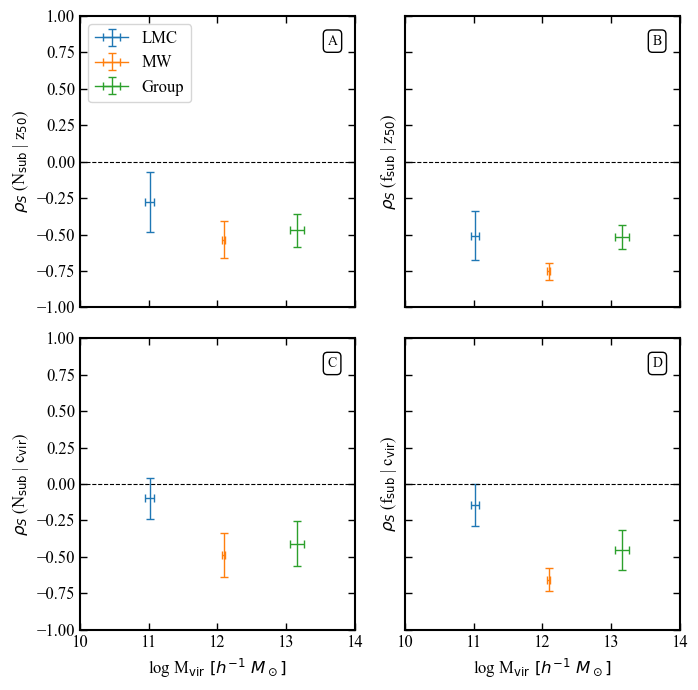

In [7]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(double_textwidth, double_textwidth),
    sharex=True,
    sharey=True
)

datasets = [LMCnorm, MWnorm, LGnorm]
colors = ["C0", "C1", "C2"]

for j, dataset in enumerate(datasets):

    axes[0, 0].errorbar(
        dataset.logMvir_bar,
        dataset.rho_80_rs[0],
        yerr=dataset.rho_err_80_rs[0],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)


    axes[1, 0].errorbar(
        dataset.logMvir_bar,
        dataset.rho_80_rs[1],
        yerr=dataset.rho_err_80_rs[1],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)


    axes[0, 1].errorbar(
        dataset.logMvir_bar,
        dataset.rho_80_rs[2],
        yerr=dataset.rho_err_80_rs[2],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)

    axes[1, 1].errorbar(
        dataset.logMvir_bar,
        dataset.rho_80_rs[3],
        yerr=dataset.rho_err_80_rs[3],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)

for ax in axes.flatten():
    ax.axhline(0, color="k", lw=0.8, ls="--")

axes[0, 0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1, 0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")

axes[0, 1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_{50}$)")
axes[1, 1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | c$_{\\rm vir}$)")

axes[0, 0].legend(loc="upper left")

axes[1, 1].set_xlim(10,14)
axes[1, 0].set_xlabel("log M$_{\\rm vir}\\ [h^{-1}\\ M_\\odot]$")
axes[1, 1].set_xlabel("log M$_{\\rm vir}\\ [h^{-1}\\ M_\\odot]$")
axes[1, 1].set_ylim(-1, 1)

axes[0,0].text(0.9, 0.9, s="A",  transform=axes[0, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white"))
axes[0,1].text(0.9, 0.9, s="B",  transform=axes[0, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white"))
axes[1,0].text(0.9, 0.9, s="C",  transform=axes[1, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white"))
axes[1,1].text(0.9, 0.9, s="D",  transform=axes[1, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white"))

plt.tight_layout()
# plt.savefig("../../figures/corr_comp.pdf", bbox_inches="tight")
plt.show()

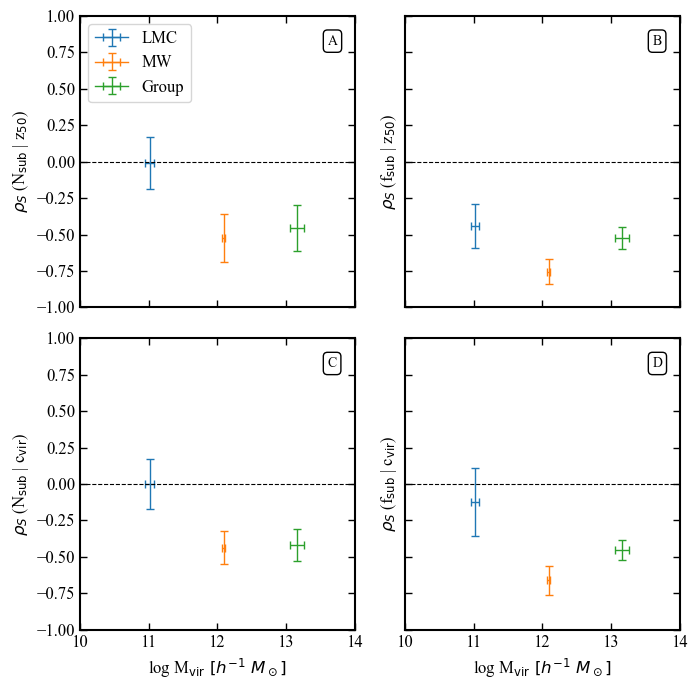

In [8]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(double_textwidth, double_textwidth),
    sharex=True,
    sharey=True
)

datasets = [LMCnorm, MWnorm, LGnorm]
colors = ["C0", "C1", "C2"]

for j, dataset in enumerate(datasets):

    axes[0, 0].errorbar(
        dataset.logMvir_bar,
        dataset.rho_85_rs[0],
        yerr=dataset.rho_err_85_rs[0],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)


    axes[1, 0].errorbar(
        dataset.logMvir_bar,
        dataset.rho_85_rs[1],
        yerr=dataset.rho_err_85_rs[1],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)


    axes[0, 1].errorbar(
        dataset.logMvir_bar,
        dataset.rho_85_rs[2],
        yerr=dataset.rho_err_85_rs[2],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)

    axes[1, 1].errorbar(
        dataset.logMvir_bar,
        dataset.rho_85_rs[3],
        yerr=dataset.rho_err_85_rs[3],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)

for ax in axes.flatten():
    ax.axhline(0, color="k", lw=0.8, ls="--")

axes[0, 0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1, 0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")

axes[0, 1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_{50}$)")
axes[1, 1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | c$_{\\rm vir}$)")

axes[0, 0].legend(loc="upper left")

axes[1, 1].set_xlim(10,14)
axes[1, 0].set_xlabel("log M$_{\\rm vir}\\ [h^{-1}\\ M_\\odot]$")
axes[1, 1].set_xlabel("log M$_{\\rm vir}\\ [h^{-1}\\ M_\\odot]$")
axes[1, 1].set_ylim(-1, 1)

axes[0,0].text(0.9, 0.9, s="A",  transform=axes[0, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white"))
axes[0,1].text(0.9, 0.9, s="B",  transform=axes[0, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white"))
axes[1,0].text(0.9, 0.9, s="C",  transform=axes[1, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white"))
axes[1,1].text(0.9, 0.9, s="D",  transform=axes[1, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white"))

plt.tight_layout()
# plt.savefig("../../figures/corr_comp.pdf", bbox_inches="tight")
plt.show()

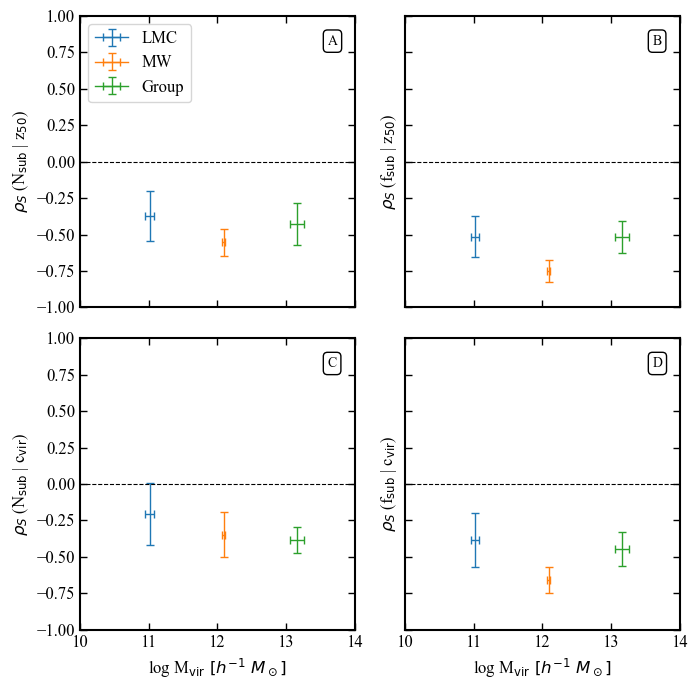

In [9]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(double_textwidth, double_textwidth),
    sharex=True,
    sharey=True
)

datasets = [LMCnorm, MWnorm, LGnorm]
colors = ["C0", "C1", "C2"]

for j, dataset in enumerate(datasets):

    axes[0, 0].errorbar(
        dataset.logMvir_bar,
        dataset.rho_90_rs[0],
        yerr=dataset.rho_err_90_rs[0],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)


    axes[1, 0].errorbar(
        dataset.logMvir_bar,
        dataset.rho_90_rs[1],
        yerr=dataset.rho_err_90_rs[1],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)


    axes[0, 1].errorbar(
        dataset.logMvir_bar,
        dataset.rho_90_rs[2],
        yerr=dataset.rho_err_90_rs[2],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)

    axes[1, 1].errorbar(
        dataset.logMvir_bar,
        dataset.rho_90_rs[3],
        yerr=dataset.rho_err_90_rs[3],
        xerr=dataset.logMvir_std,
        color=colors[j],
        capsize=3,
        lw=1,
        label=dataset.model_label)

for ax in axes.flatten():
    ax.axhline(0, color="k", lw=0.8, ls="--")

axes[0, 0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1, 0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")

axes[0, 1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_{50}$)")
axes[1, 1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | c$_{\\rm vir}$)")

axes[0, 0].legend(loc="upper left")

axes[1, 1].set_xlim(10,14)
axes[1, 0].set_xlabel("log M$_{\\rm vir}\\ [h^{-1}\\ M_\\odot]$")
axes[1, 1].set_xlabel("log M$_{\\rm vir}\\ [h^{-1}\\ M_\\odot]$")
axes[1, 1].set_ylim(-1, 1)

axes[0,0].text(0.9, 0.9, s="A",  transform=axes[0, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white"))
axes[0,1].text(0.9, 0.9, s="B",  transform=axes[0, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white"))
axes[1,0].text(0.9, 0.9, s="C",  transform=axes[1, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white"))
axes[1,1].text(0.9, 0.9, s="D",  transform=axes[1, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white"))

plt.tight_layout()
# plt.savefig("../../figures/corr_comp.pdf", bbox_inches="tight")
plt.show()

In [21]:
np.save("../../../SatGen/etc/MWx100.npy", np.array(list(MW["log_mvir"].values)*100))

In [22]:
np.save("../../../SatGen/etc/LMCx100.npy", np.array(list(LMC["log_mvir"].values)*100))

In [23]:
np.save("../../../SatGen/etc/LGx100.npy", np.array(list(LG["log_mvir"].values)*100))